In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [411]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [4]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [5]:
odir = "ps_data"
with open(f"{odir}/ics/test5.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 1.976102912


In [256]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-3/test12.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 3.952205824


In [259]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-3/test13.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.988051456


In [326]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-3/test14.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.035287552


In [402]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-2/test13.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.004410944


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


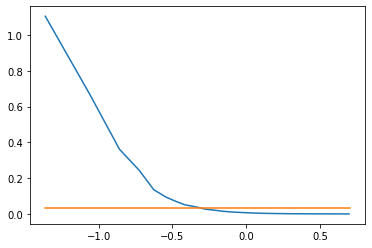

In [262]:
plt.plot(np.log10(ks[:ik]), Pk_ic["power"][:ik])
plt.plot([np.log10(ks[0]), np.log10(ks[ik])], [Pk_ic.attrs["shotnoise"],Pk_ic.attrs["shotnoise"]])

In [314]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-2/test13.pickle", "rb") as f:
    Pk_ic2 = pickle.load(f)
    
print("shotnoise", Pk_ic2.attrs["shotnoise"])

shotnoise 0.004410944


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.0, 0.1)

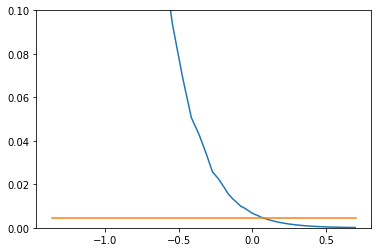

In [322]:
plt.plot(np.log10(ks[:ik]), Pk_ic2["power"][:ik])
plt.plot([np.log10(ks[0]), np.log10(ks[ik])], [Pk_ic2.attrs["shotnoise"],Pk_ic2.attrs["shotnoise"]])
plt.ylim(0,0.1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


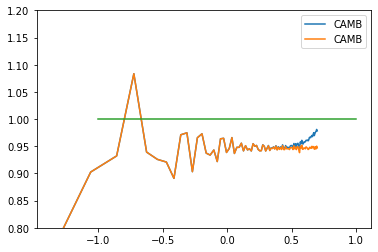

In [263]:
ik = 100
plt.plot(np.log10(ks[:ik]),(Pk_ic["power"][:ik])/Pk_lin_colossus_ic_camb[:ik], label="CAMB")
plt.plot(np.log10(ks[:ik]),(Pk_ic2["power"][:ik])/Pk_lin_colossus_ic_camb[:ik], label="CAMB")
plt.plot([-1,1], [1,1])
plt.ylim(0.8,1.2)
plt.legend()

In [66]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/test1.pickle", "rb") as f:
    Pk1 = pickle.load(f)
    
print("shotnoise", Pk1.attrs["shotnoise"])

shotnoise 0.035287552


In [99]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/test4.pickle", "rb") as f:
    Pk2 = pickle.load(f)
    
print("shotnoise", Pk2.attrs["shotnoise"])

shotnoise 0.035287552


In [6]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [318]:
Pk_ic = Pk_ic2

In [289]:
iend = 150
ks = Pk_gal10['k'][:iend]

In [290]:
from nbodykit import cosmology as cosmology_nbody

cosmo1 = cosmology_nbody.Planck15
z=1.5
Plin = cosmology_nbody.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology_nbody.power.halofit.HalofitPower(cosmo1, redshift=z) 

#k_analytical = 10**np.arange(-1.6,0,0.05)
#k_colossus = 10**np.arange(-3,0,0.02)

coef = ks**3 / (2 * np.pi **2)
# Pk_linear = Plin(ks)
# #print(Pk_linear)
# normed_Pk_matter_lin = coef * Pk_linear 
# Pk_nonlinear = Pnl(ks)
# normed_Pk_matter_nl = coef * Pk_nonlinear 

In [297]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')

In [77]:
from colossus.cosmology import power_spectrum

In [298]:
cosmo.Om0

0.3089

In [299]:
cosmo.Ob0

0.0486

In [300]:
Pk_lin_colossus = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_ic_camb = cosmo.matterPowerSpectrum(ks, 127, model="camb", ps_args=ps_args)

In [401]:
Pk_lin_colossus_ic_98 = cosmo.matterPowerSpectrum(ks, 127, model="eisenstein98")

In [302]:
Pk_lin_colossus_ic_98_zb = cosmo.matterPowerSpectrum(ks, 127, model="eisenstein98_zb")

In [303]:
Pk_lin_colossus_ic_95 = cosmo.matterPowerSpectrum(ks, 127, model="sugiyama95")

In [304]:
D127 = cosmo.growthFactorUnnormalized(127)

In [285]:
D127 = cosmo.growthFactor(127)
print(D127)

0.010212584321206945


In [95]:
ps_args = dict(model = 'camb', kmax = 1e2, ps_type = 'cdm')

P = cosmo.matterPowerSpectrum(ks, 127, **ps_args)
#variance = cosmo.sigma(R, **ps_args)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


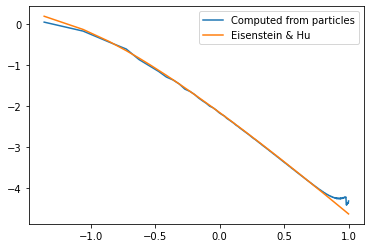

In [250]:
plt.plot(np.log10(ks),np.log10((Pk_ic["power"][:iend])), label="Computed from particles")
plt.plot(np.log10(ks),np.log10((Pk_lin_colossus_ic)), label="Eisenstein & Hu")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


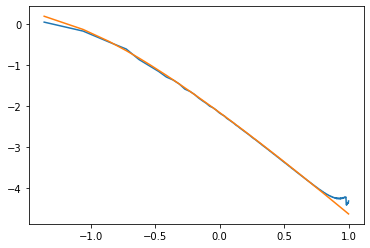

In [248]:
plt.plot(np.log10(ks),np.log10((Pk_ic["power"][:iend])))
plt.plot(np.log10(ks),np.log10((Pk_lin_colossus_ic)))

In [134]:
Pk_ic["power"][:iend]

array([1.10546508e+00+0.j, 6.68308559e-01+0.j, 3.61312797e-01+0.j,
       2.44057136e-01+0.j, 1.35409822e-01+0.j, 9.37653078e-02+0.j,
       6.90197508e-02+0.j, 5.06819526e-02+0.j, 4.27787186e-02+0.j,
       3.41543991e-02+0.j, 2.57246782e-02+0.j, 2.26865105e-02+0.j,
       1.91124299e-02+0.j, 1.56057557e-02+0.j, 1.32921923e-02+0.j,
       1.15827590e-02+0.j, 9.86541025e-03+0.j, 9.04326139e-03+0.j,
       7.97981820e-03+0.j, 6.89514084e-03+0.j, 6.20071270e-03+0.j,
       5.67692317e-03+0.j, 4.96268551e-03+0.j, 4.54001654e-03+0.j,
       4.12172081e-03+0.j, 3.78666169e-03+0.j, 3.41229041e-03+0.j,
       3.16105284e-03+0.j, 2.88086723e-03+0.j, 2.66060765e-03+0.j,
       2.44955423e-03+0.j, 2.30144675e-03+0.j, 2.12612192e-03+0.j,
       1.98196385e-03+0.j, 1.83336504e-03+0.j, 1.70755238e-03+0.j,
       1.59794370e-03+0.j, 1.51454145e-03+0.j, 1.41757481e-03+0.j,
       1.32054588e-03+0.j, 1.24984425e-03+0.j, 1.18430327e-03+0.j,
       1.10715845e-03+0.j, 1.05166714e-03+0.j, 9.94720621e-04+

In [133]:
Pk_ic.attrs["shotnoise"]

1.976102912

In [307]:
Pk_ic.attrs["shotnoise"]

0.035287552

In [ ]:
k_ic["power"][:iend]

(0.0, 2.0)

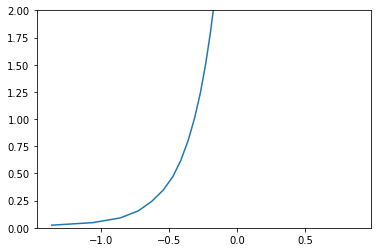

In [311]:
plt.plot(np.log10(ks),Pk_ic.attrs["shotnoise"]/Pk_lin_colossus_ic_camb)
plt.ylim(0,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


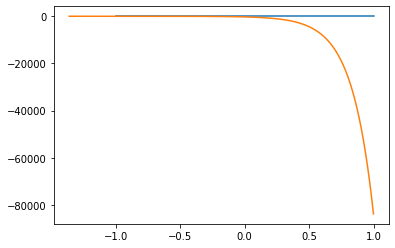

In [139]:
plt.plot([-1,1], [1,1])
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]-Pk_ic.attrs["shotnoise"])/Pk_lin_colossus_ic_camb, label="CAMB")

#plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/P, label="CAMB")
#plt.ylim(0.8,1.2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


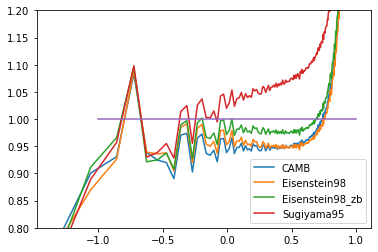

In [328]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_camb, label="CAMB")
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98, label="Eisenstein98")
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98_zb, label="Eisenstein98_zb")
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_95, label="Sugiyama95")
plt.plot([-1,1], [1,1])
plt.ylim(0.8,1.2)
plt.legend()

In [408]:
iend = len(ks)



/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

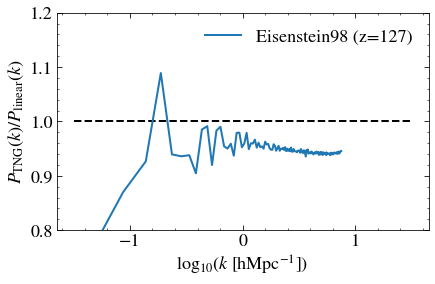

In [418]:
plt.plot([-1.5,1.5], [1,1], c="k", linestyle="dashed")
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98[:iend], label="Eisenstein98 (z=127)")

plt.ylim(0.8,1.2)
plt.legend()
plt.ylabel(r"$P_{\mathrm{TNG}}(k)/P_{\mathrm{linear}}(k)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

In [373]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-3/test1_il_py.pickle", "rb") as f:
    Pk_ic1 = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.035287552


In [375]:
ks1 = Pk_ic1["k"]

In [376]:
Pk_lin_colossus_ic_98 = cosmo.matterPowerSpectrum(ks1, 127, model="eisenstein98")

In [404]:
#plt.plot(np.log10(ks1),(Pk_ic1["power"][:iend])/Pk_lin_colossus_ic_camb, label="CAMB")
plt.plot(np.log10(ks1),(Pk_ic1["power"])/Pk_lin_colossus_ic_98, label="Eisenstein98")
#plt.plot(np.log10(ks1),(Pk_ic1["power"][:iend])/Pk_lin_colossus_ic_98_zb, label="Eisenstein98_zb")
#plt.plot(np.log10(ks1),(Pk_ic1["power"][:iend])/Pk_lin_colossus_ic_95, label="Sugiyama95")
plt.plot([-1,1], [1,1])
plt.ylim(0.8,1.2)
plt.legend()

ValueError: operands could not be broadcast together with shapes (191,) (150,) 

In [422]:
logks0, logpk0 = np.loadtxt("input_spectrum_PLANCK15.txt", unpack=True)
ks0 = 10**logks0
pk0 = 10**logpk0
Pk_lin_colossus_ic_98 = cosmo.matterPowerSpectrum(ks0, 127, model="eisenstein98")

In [394]:
Pk_lin_colossus_ic_98_2 = cosmo.matterPowerSpectrum(ks, 127, model="eisenstein98")

In [345]:
kcoef = (ks**3)/(2*np.pi**2)

In [341]:
coef0 = (ks0**3)/(2*np.pi**2)

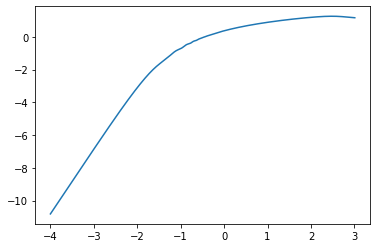

In [337]:
plt.plot(logks0, logpk0)

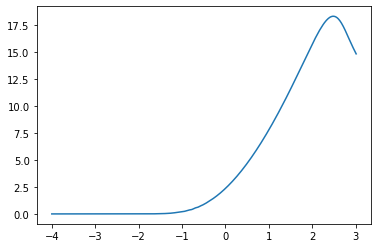

In [344]:
plt.plot(logks0, pk0)

In [ ]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]))
plt.plot(logks0, Pk_lin_colossus_ic_98)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


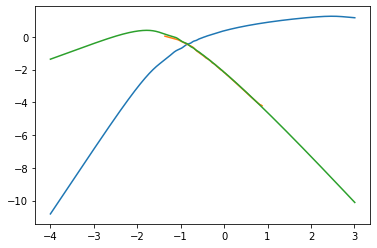

In [352]:
plt.plot(logks0, logpk0)
plt.plot(np.log10(ks),np.log10((Pk_ic["power"][:iend])))
plt.plot(logks0, np.log10(Pk_lin_colossus_ic_98))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


ValueError: x and y must have same first dimension, but have shapes (808,) and (150,)

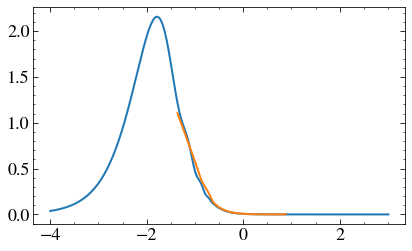

In [420]:
plt.plot(logks0, pk0/coef0/(0.8*1e4))
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]))
plt.plot(logks0, Pk_lin_colossus_ic_98)
#plt.ylim(0,0.1)
plt.xlim(-1.5,1.5,0.1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-1.5, 1.5)

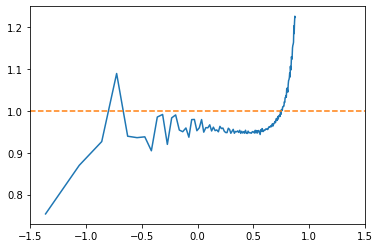

In [396]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98_2)
plt.plot([-1.5,1.5], [1,1], linestyle="dashed")
plt.xlim(-1.5,1.5)

(-1.5, 1.5)

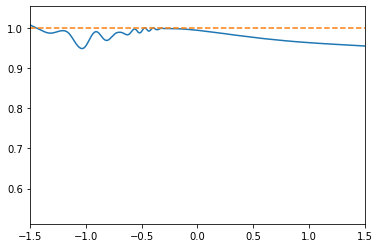

In [398]:
plt.plot(logks0, pk0/coef0/(0.67*1e4)/Pk_lin_colossus_ic_98)
plt.plot([-1.5,1.5], [1,1], linestyle="dashed")
plt.xlim(-1.5,1.5)

(-1.5, 1.5)

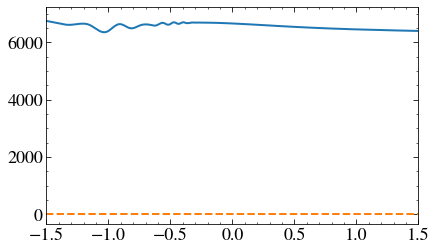

In [425]:
plt.plot(logks0, pk0/coef0/Pk_lin_colossus_ic_98)
plt.plot([-1.5,1.5], [1,1], linestyle="dashed")
plt.xlim(-1.5,1.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


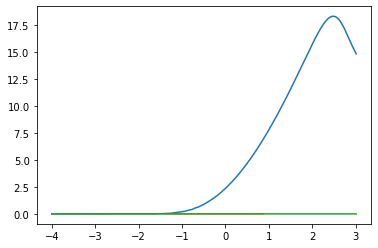

In [349]:
plt.plot(logks0, pk0)
plt.plot(np.log10(ks),(kcoef*Pk_ic["power"][:iend]))
plt.plot(logks0, coef0*Pk_lin_colossus_ic_98)

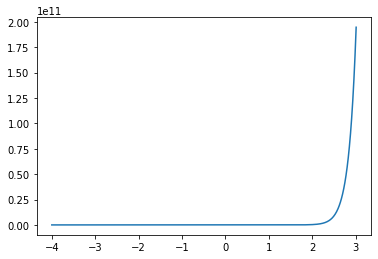

In [333]:
plt.plot(logks0,(pk0)/Pk_lin_colossus_ic_98, label="Eisenstein98")


In [254]:
2300/2500

0.92

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


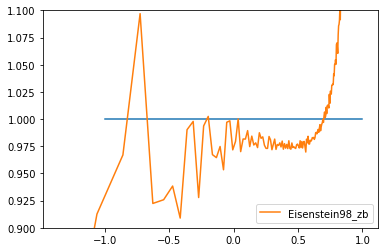

In [241]:
plt.plot([-1,1], [1,1])


plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98_zb, label="Eisenstein98_zb")
plt.ylim(0.9,1.1)
plt.legend()

In [ ]:
Pk_lin_colossus = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_ic_camb = cosmo.matterPowerSpectrum(ks, 127, model="camb")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


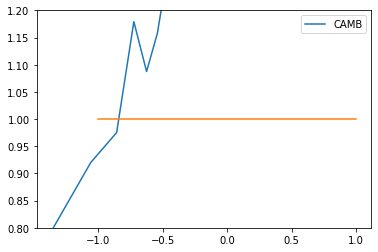

In [136]:
ik = 100
plt.plot(np.log10(ks[:ik]),(Pk2["power"][:ik])/Pk_lin_colossus[:ik], label="CAMB")
plt.plot([-1,1], [1,1])
plt.ylim(0.8,1.2)
plt.legend()

In [126]:
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(130)

In [127]:
growth_factor = (D15/D127)**2
print(growth_factor)

2482.860717969315


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


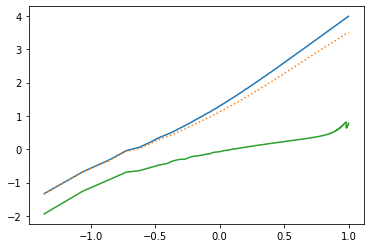

In [55]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*growth_factor), label="TNG total")

In [ ]:
Pk_lin_colossus_ic_camb

In [56]:

Pk_lin_15 = cosmo.matterPowerSpectrum(ks, 1.5, model="camb")

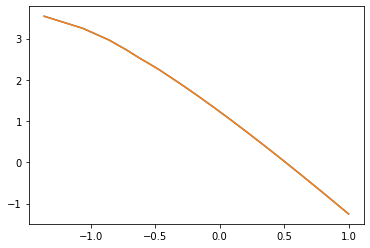

In [59]:
plt.plot(np.log10(ks), np.log10(Pk_lin_15))

plt.plot(np.log10(ks), np.log10(Pk_lin_colossus_ic_camb*growth_factor))

In [60]:
Pk_lin_15/Pk_lin_colossus_ic_camb

array([2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952001,
       2373.79952001, 2373.79952001, 2373.79952001, 2373.79952

In [63]:
Pk_gal10["power"].real/Pk_ic["power"].real

array([1.01457918e+04, 9.54997891e+03, 9.79251999e+03, 1.10060867e+04,
       1.25454126e+04, 1.42842115e+04, 1.65701158e+04, 1.85635908e+04,
       1.88490602e+04, 2.12253330e+04, 2.53322118e+04, 2.63674116e+04,
       2.93671344e+04, 3.36049869e+04, 3.70665750e+04, 4.07981981e+04,
       4.46303900e+04, 4.76239284e+04, 5.09316744e+04, 5.79606264e+04,
       6.21655283e+04, 6.55976448e+04, 7.36518689e+04, 7.83416229e+04,
       8.44709619e+04, 8.92539735e+04, 9.75936686e+04, 1.03056239e+05,
       1.12057365e+05, 1.19082036e+05, 1.27257814e+05, 1.35316409e+05,
       1.42345312e+05, 1.51478229e+05, 1.62491380e+05, 1.72841293e+05,
       1.82568214e+05, 1.91083855e+05, 2.00698943e+05, 2.14171464e+05,
       2.23958053e+05, 2.36012452e+05, 2.49977676e+05, 2.62521086e+05,
       2.71601760e+05, 2.86003345e+05, 2.98687146e+05, 3.13700762e+05,
       3.29069976e+05, 3.42105682e+05, 3.59362169e+05, 3.74216991e+05,
       3.90501011e+05, 4.04162550e+05, 4.22853910e+05, 4.37883265e+05,
      

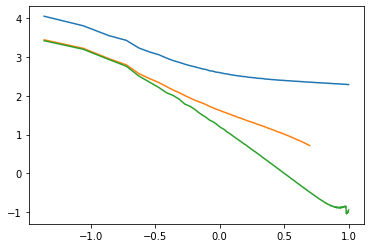

In [100]:
plt.plot(np.log10(ks), np.log10(Pk_gal10["power"].real[:iend]))
plt.plot(np.log10(ks[:100]), np.log10(Pk2["power"].real[:100]))
plt.plot(np.log10(ks), np.log10(Pk_ic["power"].real[:iend]*growth_factor))

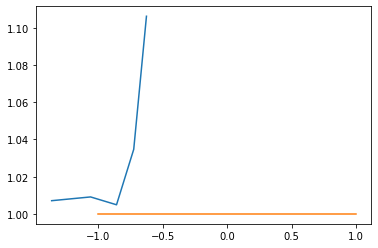

In [137]:
ik = 5
plt.plot(np.log10(ks[:ik]), Pk2["power"].real[:ik]/Pk_ic["power"].real[:ik]/growth_factor)
plt.plot([-1,1], [1,1])

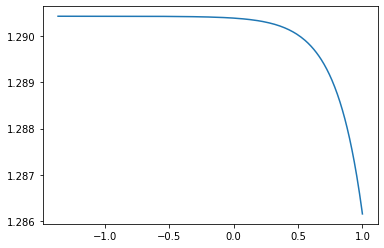

In [68]:
plt.plot(np.log10(ks), np.log10(Pk1["power"].real[:iend]))

In [161]:
import camb
from camb import model, initialpower

In [205]:
h = 0.6774
omega_b = 0.0486
omega_cdm = 0.3089
ombh2 = omega_b * h**2
omch2 = omega_cdm * h**2

In [162]:
pars = camb.set_params(H0=67.74, ombh2=omega_b, omch2=omega_cdm, redshifts=[0], kmax=5, 
                       As=2e-9, ns=0.9667, sigma halofit_version='mead')
results= camb.get_transfer_functions(pars)
kref,_,PKref = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False)
kref,_,PKnl = results.get_nonlinear_matter_power_spectrum(hubble_units=False, k_hunit=False)


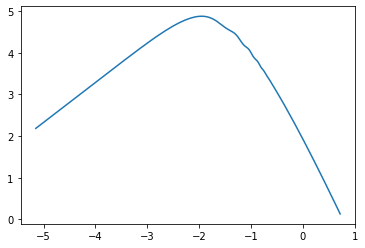

In [166]:
plt.plot(np.log10(kref), np.log10(PKref[0]))

In [225]:
pars = camb.read_ini('Planck2018_ini.txt')

In [226]:
pars.set_matter_power(redshifts=[127], kmax=2.0)

class: <CAMBparams>
 WantCls = True
 WantTransfer = True
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_both
 Transfer: <TransferParams>
   high_precision = True
   accurate_massive_neutrinos = False
   kmax = 2.0
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [127.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2700
 max_l_tensor = 600
 max_eta_k = 18000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.0223828
 omch2 = 0.1201075
 omk = 0.0
 omnuh2 = 0.0006451439
 H0 = 67.32117
 TCMB = 2.7255
 YHe = 0.2454006
 num_nu_massless = 2.046
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = True
 nu_mass_degeneracies = [0.0]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_indeptilt
   ns = 0.9660499
   nrun = 0.0
   nrunrun = 0.0
   nt

In [227]:
results = camb.get_results(pars)

In [228]:
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

In [216]:
from camb import get_matter_power_interpolator
PK = get_matter_power_interpolator(pars, hubble_units=True)

In [223]:
pk = PK(127, ks/h)

In [224]:
pk

array([[-0.22014803, -0.36700008, -0.54057251, -0.70972621, -0.87376153,
        -1.04605415, -1.2174261 , -1.38537508, -1.55824566, -1.73272309,
        -1.90569682, -2.07886468, -2.25212953, -2.42413583, -2.59713441,
        -2.76962959, -2.93944183, -3.10956879, -3.28030706, -3.44798297,
        -3.6151188 , -3.78071871, -3.94335294, -4.10600412, -4.26585287,
        -4.42272689, -4.57676209, -4.72862993, -4.87963575, -5.02738277,
        -5.17072727, -5.31199262, -5.45036555, -5.58524921, -5.71838723,
        -5.84864698, -5.97637123, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.04119055, -6.04119055,
        -6.04119055, -6.04119055, -6.04119055, -6.0

In [187]:
print(z)

[127.0]


In [232]:
interpolated = np.interp(ks, kh, pk[0])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


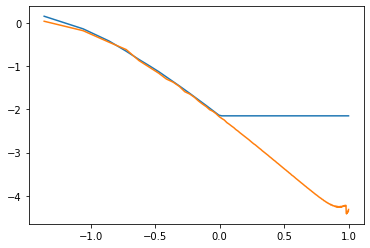

In [233]:
plt.plot(np.log10(ks), np.log10(interpolated))
plt.plot(np.log10(ks),np.log10(Pk_ic["power"][:iend]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


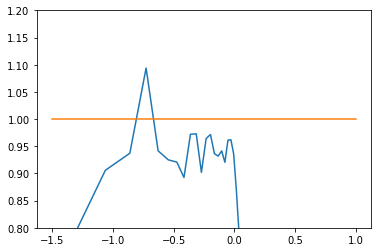

In [238]:
plt.plot(np.log10(ks), Pk_ic["power"][:iend]/interpolated)
plt.ylim(0.8,1.2)
plt.plot([-1.5,1],[1,1])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


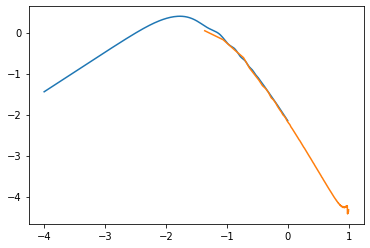

In [231]:
plt.plot(np.log10(kh), np.log10(pk[0]))
plt.plot(np.log10(ks),np.log10(Pk_ic["power"][:iend]))